In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src.features import make_features, make_targets, attach_store_data
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

N_STORES = 3
DAYS     = 500
FORECAST_HORIZON = 15

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)

def make_synthetic_sales_data():
    dates    = pd.date_range("2013-01-01", periods=DAYS, freq="D")
    rows = []
    rng  = np.random.default_rng(C.SEED)
    for store_id in range(1, N_STORES + 1):
        base = 300 + store_id * 150          # stores differ in overall level
        for date in dates:
            dow      = date.dayofweek + 1    # 1=Mon … 7=Sun
            is_sun   = dow == 7
            seasonal = base + 20 * np.sin(2 * np.pi * (dow - 1) / 6)   # peak Wed
            trend    = 0.15 * (date - dates[0]).days
            promo    = int(rng.random() < 0.25)
            sales    = max(0.0, seasonal + trend + promo * 100) if not is_sun else 0.0
            rows.append({
                "Date":          date,
                "Store":         store_id,
                "DayOfWeek":     dow,
                "Open":          0 if is_sun else 1,
                "Promo":         promo,
                "StateHoliday":  "0",
                "SchoolHoliday": 0,
                "Sales":         sales,
            })

    train = pd.DataFrame(rows)

    return train

def make_synthetic_store_data():

    stores = pd.DataFrame({
        "Store":               list(range(1, N_STORES + 1)),
        "StoreType":           ["a", "b", "c"],
        "Assortment":          ["a", "a", "b"],
        "CompetitionDistance": [500.0, 1200.0, 800.0],
        "CompetitionSinceDate": pd.to_datetime(["2012-03-01", "2011-06-01", "2013-01-01"]),
        "Promo2SinceDate":     pd.to_datetime(["2012-06-01", pd.NaT,       "2013-03-01"]),
        "PromoInterval":       ["Jan,Apr,Jul,Oct", None,                   "Mar,Jun,Sep,Dec"],
    })

    return stores


c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate  Promo2
         2     1      0            0              0 467.320508         a          a                500.0           2012-03-01      2012-06-01       1
         2     1      0            0              0 617.320508         b          a               1200.0           2011-06-01             NaT       0
         2     1      1            0              0 867.320508         c          b                800.0           2013-01-01      2013-03-01       0
         3     1      0            0              0 467.470508         a          a                500.0           2012-03-01      2012-06-01       1
         3     1      0            0              0 617.470508         b          a               1200.0           2011-06-01             NaT       0


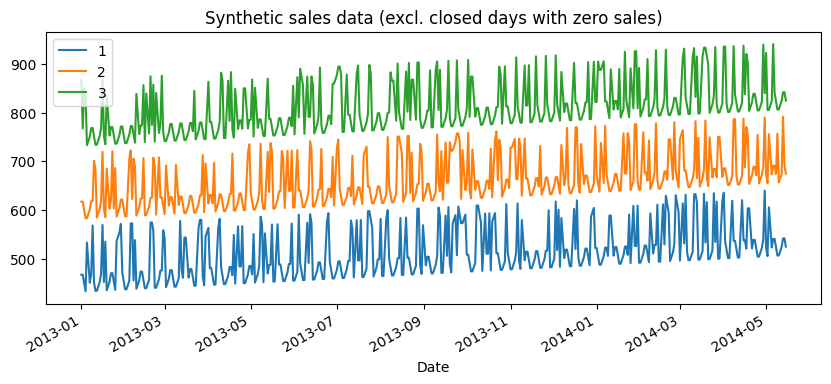

In [2]:
stores = make_synthetic_store_data()
train = make_synthetic_sales_data()
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": 80, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [4]:

# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)
df_processed = df.copy()
df_processed['Sales'] = utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
df_processed['Sales'] = df_processed['Sales'].groupby(level='Store').diff()
X = make_features(df_processed, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
y = make_targets(df_processed['Sales'], C.FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break


[0]	train-rmse:53.79900+0.80175	test-rmse:53.59162+1.54651
[0]	train-rmse:53.60314+0.80691	test-rmse:53.56463+1.54129
[0]	train-rmse:53.71478+0.79891	test-rmse:53.58373+1.54295
[0]	train-rmse:53.58201+0.79722	test-rmse:53.57681+1.56141
[100]	train-rmse:50.64175+0.87420	test-rmse:53.21279+1.62744
[28]	train-rmse:48.98381+0.82013	test-rmse:53.35098+1.66693
[0]	train-rmse:53.73301+0.80481	test-rmse:53.58660+1.54325
[130]	train-rmse:49.94321+0.87077	test-rmse:53.20548+1.63713
[0]	train-rmse:53.75970+0.79913	test-rmse:53.60052+1.54813
[30]	train-rmse:46.97185+0.91374	test-rmse:53.46937+1.65050
[0]	train-rmse:52.97154+0.82127	test-rmse:53.55767+1.54540
[41]	train-rmse:48.94527+0.86258	test-rmse:53.30947+1.59513
[0]	train-rmse:52.83333+0.76570	test-rmse:53.56106+1.56012
[63]	train-rmse:47.94666+0.83736	test-rmse:53.28827+1.61863
[0]	train-rmse:53.09613+0.82818	test-rmse:53.50388+1.56703
[0]	train-rmse:53.42773+0.84386	test-rmse:53.51248+1.51236
[0]	train-rmse:51.84171+0.83819	test-rmse:53.448

In [5]:
booster_file_1 = f"C:\\Users\\m_kal\\Downloads\\rossmann_store_sales\\artifacts\\fold_1\\trial_{study.best_trial.number:04d}\\fold_3.ubj"
booster_file_2 = os.path.join(study_config["log_dir"], study_name, "model.ubj")
bfiles = [booster_file_2, booster_file_1]

for booster_file in bfiles:

    booster = xgb.Booster()
    booster.load_model(booster_file)
    preds = utils.predict(booster, X_test)

    # ------------------------------------------------------------------------------
    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = utils.overwrite_closed_sales(df['Sales'], mode='interpolate').loc[origin_index].set_axis(preds.index)
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    # ------------------------------------------------------------------------------

    actuals_idx = preds.index.droplevel("Date").swaplevel()  # (Forecast Date, Store)
    true_vals = df.loc[actuals_idx, "Sales"]

    m = compute_metrics(true_vals.values, preds.values)
    print(f"Metrics for {booster_file}: {m}")

Metrics for ./artifacts\fold_1\model.ubj: {'MAE': 46.486, 'RMSE': 61.266, 'MAPE': 6.732, 'RMSPE': 8.798}
Metrics for C:\Users\m_kal\Downloads\rossmann_store_sales\artifacts\fold_1\trial_0088\fold_3.ubj: {'MAE': 49.61, 'RMSE': 64.888, 'MAPE': 7.211, 'RMSPE': 9.336}


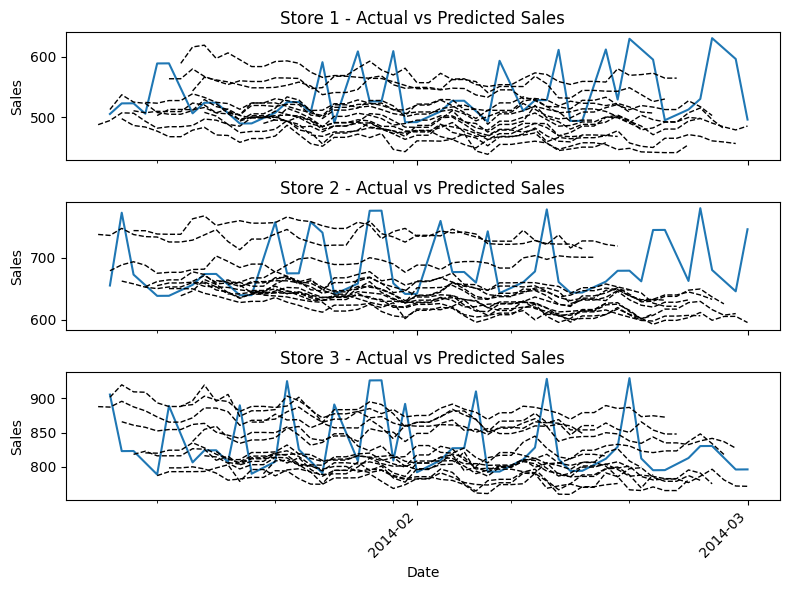

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

actual = df['Sales']

def plot_actual_vs_predicted(actual, preds):
        
    stores = actual.index.get_level_values("Store").unique()
    fig, ax = plt.subplots(figsize=(8, 6), nrows=len(stores), sharex=True, sharey=False)

    for i, store in enumerate(stores):

        actual_store_sales = (utils.retrieve_sales(actual, preds.index)
                            .loc[(slice(None), store)]
                            .sort_index())
        
        predicted_store_sales = (preds
                                .loc[(slice(None), store, slice(None))]
                                .reset_index())

        # exclude closed days with zero sales and zero predictions
        actual_store_sales = actual_store_sales[actual_store_sales > 0]
        predicted_store_sales = predicted_store_sales[predicted_store_sales[0] > 0]

        actual_store_sales.plot(label=f"Store {store}", ax=ax[i])
        (predicted_store_sales
        .groupby("Date")
        .plot(x="Forecast Date", y=0, ax=ax[i], color='k', linestyle='--', linewidth=1))

        ax[i].get_legend().remove()
        ax[i].set_title(f"Store {store} - Actual vs Predicted Sales")
        ax[i].set_ylabel("Sales")
        
    # Rotate x labels and set date format
    ax[-1].xaxis.set_major_locator(mdates.MonthLocator())
    ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    ax[-1].set_xlabel("Date")
    plt.tight_layout()

    return 

plot_actual_vs_predicted(actual, preds)